# Final evaluation (official BANKING77 test set)

## Course connection

The evaluation combines the classification metrics and error-analysis practices used throughout the course with the project requirement to explain which banking intents remain difficult.

## Step 1 — Freeze the evaluation boundary

**What this does:** loads the official test split only after model selection is complete.

**Why:** using the test set earlier would make the final scores optimistic and scientifically invalid.


In [1]:
# All models below are evaluated on the same untouched test queries.
# Use the official test split only now, after model selection is complete.
import sys
from pathlib import Path
root = Path.cwd().parent
sys.path.insert(0, str(root))
import gc, json, time
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from transformers import AutoModelForSequenceClassification, AutoTokenizer, DataCollatorWithPadding
from src.data.load_data import load_banking77
from src.models.bilstm import build_vocab, collate_batch, BiLSTMClassifier
from src.models.transformer import MODEL_NAME
from src.evaluation.evaluate import classification_metrics
from src.utils import set_seed, get_device
set_seed(42)
device = get_device(); dataset = load_banking77(validation_size=0.1, seed=42); test = dataset["test"]
texts, labels = test["text"], test["label"]
rows = []; predictions = {}

## Step 2 — Evaluate the classical baseline

**What this does:** retrains the TF-IDF baseline on training data and predicts the official test set.

**Why:** this gives the neural models a fair, reproducible reference point.


In [2]:
# E0 is the lexical reference against which the neural approaches are compared.
# E0 is a lexical reference point for the neural models.
# E0: TF-IDF + Logistic Regression
train = dataset["train"]
model = Pipeline([ ("tfidf", TfidfVectorizer(ngram_range=(1, 2), min_df=2)), ("classifier", LogisticRegression(max_iter=1000)) ])
model.fit(train["text"], train["label"]); pred = model.predict(texts); predictions["E0_tfidf"] = pred.tolist(); rows.append({"experiment":"E0_tfidf", **classification_metrics(labels, pred)})

## Step 3 — Evaluate the BiLSTM

**What this does:** rebuilds the training vocabulary, loads the best checkpoint, and predicts test labels.

**Why:** the exact preprocessing used during training must be reused during evaluation.


In [3]:
# Rebuild the same training-only vocabulary before loading the saved BiLSTM weights.
# Reload the best BiLSTM checkpoint and evaluate it on exactly the same queries.
# E1: trained BiLSTM
vocab = build_vocab(train["text"]); loader = DataLoader(list(zip(texts, labels)), batch_size=64, shuffle=False, collate_fn=lambda b: collate_batch(b, vocab)); bilstm = BiLSTMClassifier(len(vocab), num_classes=77).to(device); bilstm.load_state_dict(torch.load(root / "results/bilstm_best.pt", map_location=device)); bilstm.eval(); pred=[]
with torch.no_grad():
    for inputs, lengths, _ in loader: pred.extend(bilstm(inputs.to(device), lengths.to(device)).argmax(1).cpu().tolist())
predictions["E1_bilstm"] = pred; rows.append({"experiment":"E1_bilstm", **classification_metrics(labels, pred)})

## Step 4 — Evaluate the Transformer checkpoints

**What this does:** tokenizes test queries and evaluates frozen, fine-tuned, and learning-rate checkpoints.

**Why:** one helper keeps padding, truncation, device placement, and prediction logic consistent across Transformer variants.


In [4]:
# The helper evaluates one saved checkpoint at a time and releases memory between models.
# This helper keeps tokenization and padding identical to the Transformer runs.
def transformer_predictions(checkpoint):
    tokenizer = AutoTokenizer.from_pretrained(root / checkpoint)
    model = AutoModelForSequenceClassification.from_pretrained(root / checkpoint).to(device).eval()
    tokenized = dataset["test"].map(lambda b: tokenizer(b["text"], truncation=True, max_length=64), batched=True).remove_columns(["text"])
    tokenized.set_format("torch"); collator = DataCollatorWithPadding(tokenizer=tokenizer, return_tensors="pt")
    loader = DataLoader(tokenized, batch_size=32, shuffle=False, collate_fn=collator); out=[]
    with torch.no_grad():
        for batch in loader:
            batch={k:v.to(device) for k,v in batch.items()}; out.extend(model(**batch).logits.argmax(1).cpu().tolist())
    del model, tokenizer, loader; gc.collect(); torch.cuda.empty_cache() if torch.cuda.is_available() else None
    return out
for name, checkpoint in [("E2_frozen_distilbert", "results/04_distilbert_frozen_checkpoint"), ("E3_finetuned_distilbert", "results/05_distilbert_finetuning_checkpoint"), ("E4_lr_5e-5", "results/06_experiments_lr_5e-5_checkpoint")]:
    pred=transformer_predictions(checkpoint); predictions[name]=pred; rows.append({"experiment":name, **classification_metrics(labels, pred)})

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Map:   0%|          | 0/3080 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Map:   0%|          | 0/3080 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Map:   0%|          | 0/3080 [00:00<?, ? examples/s]

## Step 5 — Save evidence for the report

**What this does:** writes aggregate metrics, predictions, per-class scores, and the confusion matrix.

**Why:** saved artifacts make the report auditable instead of relying on copied numbers.


In [5]:
# Save raw predictions as well as summary metrics so errors can be inspected later.
# Save both aggregate and class-level evidence so conclusions can be checked later.
metrics = pd.DataFrame(rows); Path(root / "results").mkdir(exist_ok=True); metrics.to_csv(root / "results/metrics.csv", index=False); pd.DataFrame(predictions).assign(text=texts, label=labels).to_csv(root / "results/predictions/test_predictions.csv", index=False); print(metrics.to_string(index=False))
# Save per-class details and the full confusion matrix for the best validation configuration.
best_name = "E3_finetuned_distilbert"; report = classification_report(labels, predictions[best_name], output_dict=True, zero_division=0); pd.DataFrame(report).T.to_csv(root / "results/per_class_metrics.csv"); np.savetxt(root / "results/confusion_matrix.csv", confusion_matrix(labels, predictions[best_name]), delimiter=",", fmt="%d")

             experiment  accuracy  macro_precision  macro_recall  macro_f1  weighted_f1
               E0_tfidf  0.856169         0.866923      0.856169  0.855794     0.855794
              E1_bilstm  0.808766         0.818619      0.808766  0.809235     0.809235
   E2_frozen_distilbert  0.156494         0.182623      0.156494  0.106656     0.106656
E3_finetuned_distilbert  0.910390         0.917287      0.910390  0.910573     0.910573
             E4_lr_5e-5  0.910390         0.916198      0.910390  0.910449     0.910449


## Step 6 — Visualize the final comparison

**What this does:** plots test Macro-F1 for every experiment.

**Why:** Macro-F1 is the primary metric because every one of the 77 intents should contribute equally.

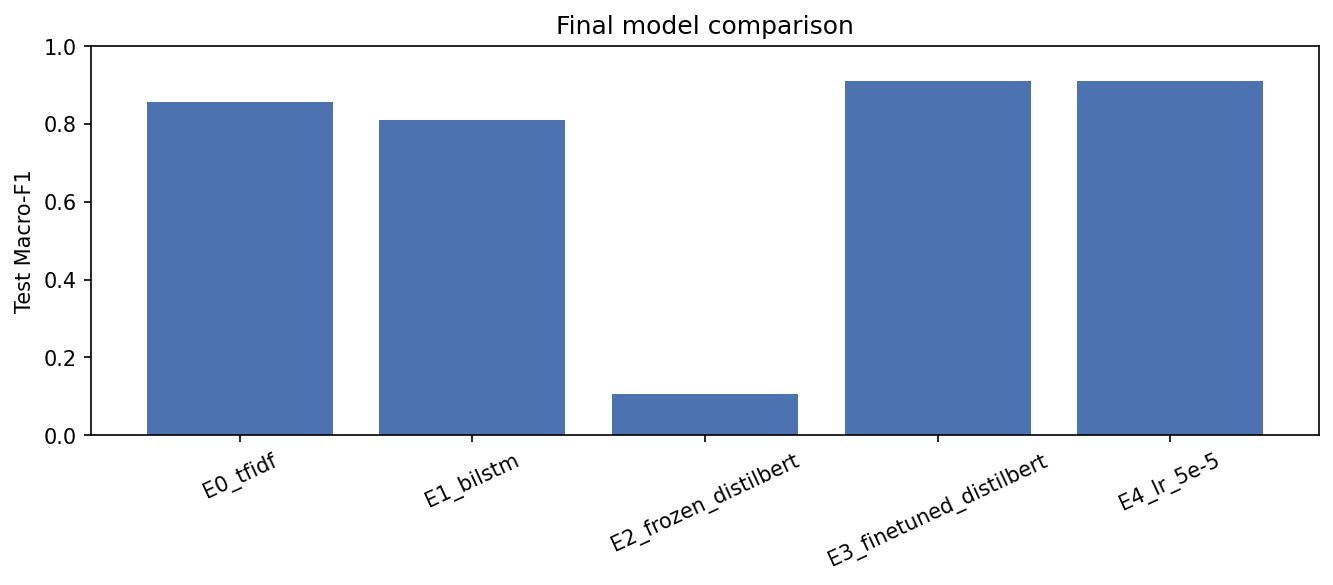

In [ ]:
# Use the common metrics file so every bar comes from the same final evaluation.
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

root = Path.cwd().parent
metrics = pd.read_csv(root / "results/metrics.csv")
plt.figure(figsize=(9, 4))
plt.bar(metrics["experiment"], metrics["macro_f1"], color="#4C72B0")
plt.ylim(0, 1)
plt.ylabel("Test Macro-F1")
plt.title("Final model comparison")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

## Step 7 — Visualize the most common errors

**What this does:** plots the ten most frequent confusion pairs from the final predictions.

**Why:** an aggregate score tells us how often the model is wrong; confusion pairs help explain where the banking intents overlap semantically.

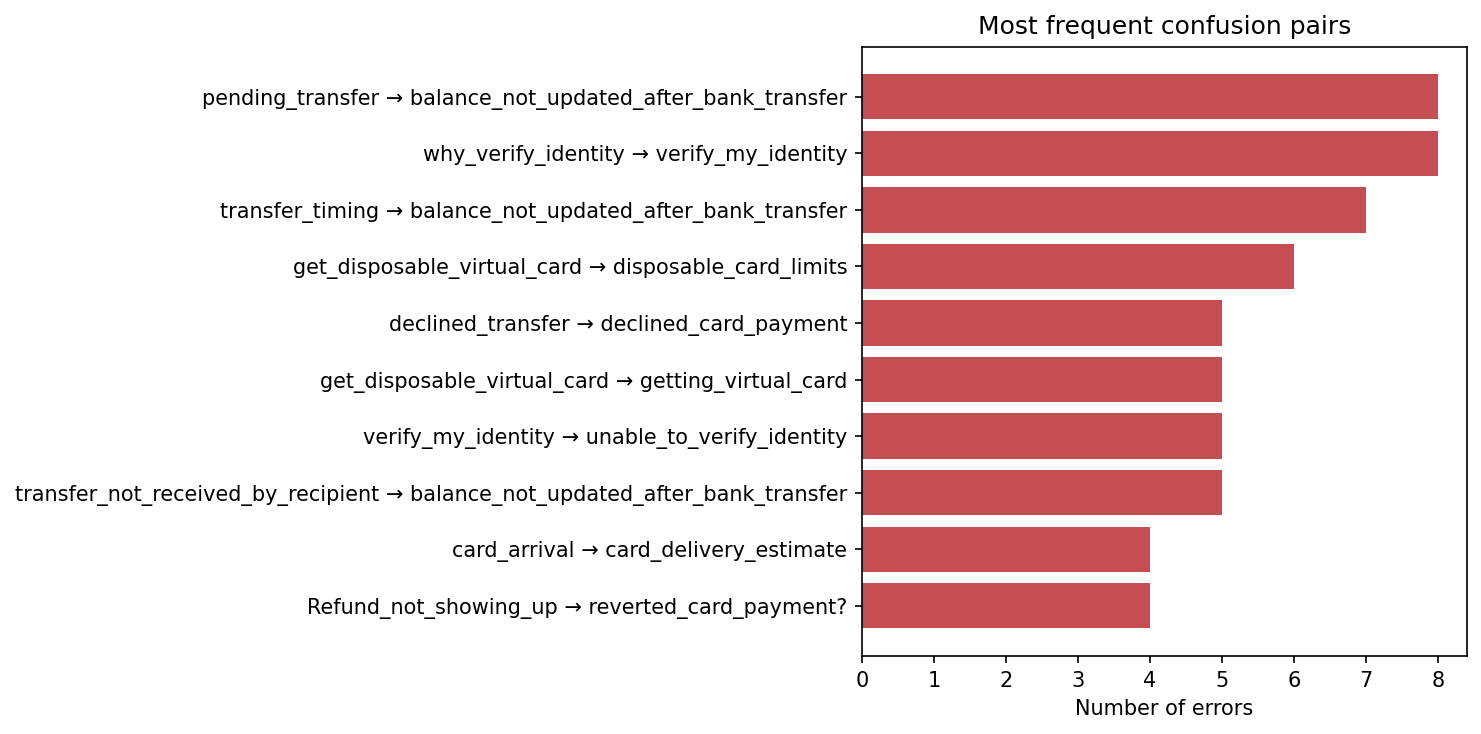

In [ ]:
# Read the saved confusion table so the error-analysis plot is reproducible.
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

root = Path.cwd().parent
confusions = pd.read_csv(root / "results/top_confusions.csv").head(10).sort_values("count")
labels = confusions["true_intent"] + " → " + confusions["predicted_intent"]
plt.figure(figsize=(10, 5))
plt.barh(labels, confusions["count"], color="#C44E52")
plt.xlabel("Number of errors")
plt.title("Most frequent confusion pairs")
plt.tight_layout()
plt.show()